# Grammar Motif Analysis by HMM Regime
This notebook mirrors the catRQA analysis to test whether HMM regimes differ in the symbolic microstructure of joint affect sequences using grammar-style motif statistics (shuffle null only).

In [1]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import kruskal, spearmanr
import scikit_posthocs as sp
import yaml

# plotting defaults
sns.set(style="whitegrid", font="Times New Roman")
plt.rcParams["svg.fonttype"] = "none"  # editable text in SVG

In [2]:
# --- 1) Load config and data ---
project_root = Path.cwd().parent
with open(project_root / "configs/analysis.yaml") as f:
    cfg = yaml.safe_load(f)

ga_cfg = cfg["analysis"]["joint_affect_grammar"]
hmm_dir = project_root / ga_cfg["hmm_dir"]
out_dir = project_root / ga_cfg["out_dir"]
figure_dir = out_dir / "notebook_figures"
figure_dir.mkdir(parents=True, exist_ok=True)

# Load grammar episode results (script output)
episode_df = pd.read_csv(out_dir / "grammar_episode_results.csv")

# Use shuffle-only stats; ignore Markov columns entirely
shuffle_cols = [c for c in episode_df.columns if "_shuffle" in c or c.endswith("_shuffle") or c.endswith("_two_shuffle") or c.endswith("_hi_shuffle") or c.endswith("_lo_shuffle") or c.endswith("_z_shuffle")]

# Keep only k in {2,3}
episode_df = episode_df[episode_df["k"].isin([2, 3])].copy()

# Load HMM regime labels for regime_class mapping
with open(hmm_dir / "best_model.json") as f:
    hmm_params = json.load(f)
pT = np.array(hmm_params["pT"])
pC = np.array(hmm_params["pC"])
regime_classes = []
for k_idx in range(pT.shape[0]):
    t_val = ["Tneg", "Tneu", "Tpos"][np.argmax(pT[k_idx, :])]
    c_val = ["Cneg", "Cneu", "Cpos"][np.argmax(pC[k_idx, :])]
    regime_classes.append(f"{t_val}-{c_val}")

# Canonical ordering (match catRQA): sort by therapist valence, then client valence, then hashed emissions
therapist_valence = np.argmax(pT, axis=1)
client_valence = np.argmax(pC, axis=1)
sort_key = (
    therapist_valence * 1_000_000
    + client_valence * 1_000
    + np.array([(hash(str(pT[k])) + hash(str(pC[k]))) % 1000 for k in range(pT.shape[0])])
 )
order = np.argsort(sort_key)
order_rank = {reg: i for i, reg in enumerate(order)}
regime_class_by_regime = {k: regime_classes[k] for k in range(len(regime_classes))}

# Keep only episodes with valid shuffle stats and enough windows
MIN_NULL_WINDOWS = 30  # aligns with script defaults
shuffle_z_cols = ["motif_entropy_z_shuffle","effective_motif_count_z_shuffle","top_mass_top_n_z_shuffle","repeat_rate_z_shuffle","motif_transition_diversity_z_shuffle"]
episode_df = episode_df[episode_df["n_windows"] >= MIN_NULL_WINDOWS]
episode_df = episode_df.dropna(subset=shuffle_z_cols)

# Add regime class
episode_df["regime_class"] = episode_df["regime"].map(regime_class_by_regime)

In [3]:
# --- 2) Episode -> session -> dyad aggregation (length-weighted) ---
metrics = [
    "motif_entropy_z_shuffle",
    "effective_motif_count_z_shuffle",
    "top_mass_top_n_z_shuffle",
    "repeat_rate_z_shuffle",
    "motif_transition_diversity_z_shuffle",
]

# helper
def weighted_mean(df, value_col, weight_col):
    total_w = df[weight_col].sum()
    if total_w == 0:
        return np.nan
    return (df[value_col] * df[weight_col]).sum() / total_w

# session-level aggregation (within session/regime/k)
session_level = (
    episode_df.groupby(["session_id", "dyad_id", "regime", "regime_class", "k"]).apply(
        lambda df: pd.Series({
            **{m: weighted_mean(df, m, "duration") for m in metrics},
            "total_duration": df["duration"].sum(),
            "n_episodes": len(df),
        })
    )
    .reset_index()
)

# dyad-level aggregation (within dyad/regime/k)
dyad_level = (
    session_level.groupby(["dyad_id", "regime", "regime_class", "k"]).apply(
        lambda df: pd.Series({
            **{m: weighted_mean(df, m, "total_duration") for m in metrics},
            "total_duration": df["total_duration"].sum(),
            "n_sessions": len(df),
        })
    )
    .reset_index()
)

# Filter to regimes that appear in data and build ordered category for plotting
present_regimes = sorted(dyad_level["regime"].unique())
class_order = []
for reg in order:
    if reg in present_regimes:
        rc = regime_class_by_regime[reg]
        if rc not in class_order:
            class_order.append(rc)
dyad_level = dyad_level.copy()
dyad_level["regime_class"] = pd.Categorical(dyad_level["regime_class"], categories=class_order, ordered=True)

print("Episode rows:", len(episode_df))
print("Session rows:", len(session_level))
print("Dyad rows:", len(dyad_level))
dyad_level.head()

Episode rows: 1579
Session rows: 511
Dyad rows: 435


/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_26322/1408799965.py:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  episode_df.groupby(["session_id", "dyad_id", "regime", "regime_class", "k"]).apply(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_26322/1408799965.py:31: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  session_level.groupby(["dyad_id", "regime", "regime_class", "k"]).ap

,dyad_id,regime,regime_class,k,motif_entropy_z_shuffle,effective_motif_count_z_shuffle,top_mass_top_n_z_shuffle,repeat_rate_z_shuffle,motif_transition_diversity_z_shuffle,total_duration,n_sessions
0,2,0,Tpos-Cpos,2,0.339278,0.340476,-0.409952,-0.195343,0.201986,291.0,2.0
1,2,0,Tpos-Cpos,3,0.177282,0.170266,-0.116872,-0.073226,0.088889,291.0,2.0
2,2,1,Tneu-Cneu,2,0.204124,0.204124,0.000000,-0.269731,0.267781,36.0,1.0
3,2,1,Tneu-Cneu,3,0.312549,0.315880,0.000000,-0.385503,0.380675,36.0,1.0
4,2,5,Tneu-Cneu,2,0.359114,0.356728,0.102301,-0.403571,0.378230,335.0,2.0


In [4]:
# --- 3) Sanity checks (brief) ---
for k_val in [2, 3]:
    sub = episode_df[episode_df["k"] == k_val]
    print(f"\nSanity for k={k_val} (episode-level):")
    for m in metrics:
        vals = sub[m].dropna()
        print(f"  {m}: mean={vals.mean():.3f}, sd={vals.std():.3f}, n={len(vals)}")
    # duration correlations (episode-level)
    for m in metrics:
        vals = sub[[m, "duration"]].dropna()
        if len(vals) > 2:
            rho, p = spearmanr(vals[m], vals["duration"])
            print(f"    corr(duration,{m}) rho={rho:.3f}, p={p:.3f}")


Sanity for k=2 (episode-level):
  motif_entropy_z_shuffle: mean=0.126, sd=0.815, n=822
  effective_motif_count_z_shuffle: mean=0.126, sd=0.818, n=822
  top_mass_top_n_z_shuffle: mean=0.015, sd=0.852, n=822
  repeat_rate_z_shuffle: mean=-0.199, sd=0.910, n=822
  motif_transition_diversity_z_shuffle: mean=0.191, sd=0.906, n=822
    corr(duration,motif_entropy_z_shuffle) rho=-0.020, p=0.569
    corr(duration,effective_motif_count_z_shuffle) rho=-0.020, p=0.559
    corr(duration,top_mass_top_n_z_shuffle) rho=0.075, p=0.032
    corr(duration,repeat_rate_z_shuffle) rho=0.003, p=0.935
    corr(duration,motif_transition_diversity_z_shuffle) rho=-0.019, p=0.579

Sanity for k=3 (episode-level):
  motif_entropy_z_shuffle: mean=0.123, sd=0.831, n=757
  effective_motif_count_z_shuffle: mean=0.121, sd=0.842, n=757
  top_mass_top_n_z_shuffle: mean=0.042, sd=0.815, n=757
  repeat_rate_z_shuffle: mean=-0.168, sd=0.924, n=757
  motif_transition_diversity_z_shuffle: mean=0.151, sd=0.913, n=757
    corr(

In [5]:
# --- 4) Regime-level statistical tests (Kruskal + Dunn) ---
from collections import defaultdict

kw_rows = []
dunn_sig_pairs = defaultdict(list)  # (k, metric) -> list of (pair, p)
dunn_rows = []  # collect all pairwise contrasts
for k_val in [2, 3]:
    sub = dyad_level[dyad_level["k"] == k_val].dropna(subset=metrics)
    for m in metrics:
        groups = [sub.loc[sub["regime"] == reg, m].dropna().values for reg in present_regimes if reg in sub["regime"].unique()]
        groups = [g for g in groups if len(g) > 0]
        if len(groups) < 2:
            continue
        H, p_kw = kruskal(*groups)
        kw_rows.append({"k": k_val, "metric": m, "H": H, "p": p_kw})
        if p_kw < 0.05:
            dunn = sp.posthoc_dunn(sub, val_col=m, group_col="regime", p_adjust="bonferroni")
            # collect all pairwise contrasts (i<j)
            for i, reg_i in enumerate(dunn.index):
                for j, reg_j in enumerate(dunn.columns):
                    if j <= i:
                        continue
                    p_val = dunn.iloc[i, j]
                    pair = f"R{reg_i+1} vs R{reg_j+1}"
                    dunn_rows.append({"k": k_val, "metric": m, "pair": pair, "p": p_val})
                    if p_val < 0.05:
                        dunn_sig_pairs[(k_val, m)].append((pair, p_val))

kw_table = pd.DataFrame(kw_rows).sort_values(["k", "p"]) 
print("Kruskal-Wallis results (sorted by k then p):")
display(kw_table)

# Display all pairwise Dunn contrasts in a compact table (sorted)
if dunn_rows:
    dunn_df = pd.DataFrame(dunn_rows).sort_values(["k", "metric", "p"])
    print('\nAll pairwise Dunn contrasts (Bonferroni-corrected p-values):')
    display(dunn_df)
else:
    print('\nNo pairwise Dunn contrasts were computed.')

# Build compact textual summary of notable contrasts (p<0.01)
summary_lines = []
for (k_val, m), pairs in dunn_sig_pairs.items():
    strong = [f"{pair} (p={p:.3g})" for pair, p in pairs if p < 0.01]
    if strong:
        summary_lines.append(f"k={k_val}, {m}: " + "; ".join(strong))
if summary_lines:
    print("\nNotable contrasts (p<0.01):")
    for line in summary_lines:
        print("  - " + line)
else:
    print("\nNo pairwise contrasts below p<0.01.")

Kruskal-Wallis results (sorted by k then p):


,k,metric,H,p
4,2,motif_transition_diversity_z_shuffle,54.802579,1.631398e-09
3,2,repeat_rate_z_shuffle,52.386294,4.899437e-09
2,2,top_mass_top_n_z_shuffle,30.812900,6.731286e-05
0,2,motif_entropy_z_shuffle,18.740611,9.039929e-03
1,2,effective_motif_count_z_shuffle,18.628093,9.435760e-03
9,3,motif_transition_diversity_z_shuffle,53.164581,3.439848e-09
8,3,repeat_rate_z_shuffle,47.665729,4.138520e-08
5,3,motif_entropy_z_shuffle,20.117717,5.320952e-03
6,3,effective_motif_count_z_shuffle,19.983144,5.606206e-03
7,3,top_mass_top_n_z_shuffle,19.646563,6.385891e-03



All pairwise Dunn contrasts (Bonferroni-corrected p-values):


,k,metric,pair,p
32,2,effective_motif_count_z_shuffle,R1 vs R6,0.019373
30,2,effective_motif_count_z_shuffle,R1 vs R4,0.121345
28,2,effective_motif_count_z_shuffle,R1 vs R2,1.000000
29,2,effective_motif_count_z_shuffle,R1 vs R3,1.000000
31,2,effective_motif_count_z_shuffle,R1 vs R5,1.000000
...,...,...,...,...
219,3,top_mass_top_n_z_shuffle,R5 vs R7,1.000000
220,3,top_mass_top_n_z_shuffle,R5 vs R8,1.000000
221,3,top_mass_top_n_z_shuffle,R6 vs R7,1.000000
222,3,top_mass_top_n_z_shuffle,R6 vs R8,1.000000



Notable contrasts (p<0.01):
  - k=2, top_mass_top_n_z_shuffle: R1 vs R6 (p=0.000246)
  - k=2, repeat_rate_z_shuffle: R1 vs R4 (p=1.5e-05); R1 vs R6 (p=2.62e-07)
  - k=2, motif_transition_diversity_z_shuffle: R1 vs R4 (p=5.32e-06); R1 vs R6 (p=1.65e-07)
  - k=3, repeat_rate_z_shuffle: R1 vs R4 (p=0.00107); R1 vs R6 (p=3.89e-06); R3 vs R4 (p=0.0039); R3 vs R6 (p=0.000652)
  - k=3, motif_transition_diversity_z_shuffle: R1 vs R4 (p=0.00033); R1 vs R6 (p=2.64e-06); R3 vs R4 (p=0.000686); R3 vs R6 (p=0.000159)


/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_26322/807743342.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_26322/807743342.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_26322/807743342.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_26322/807743342.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and w

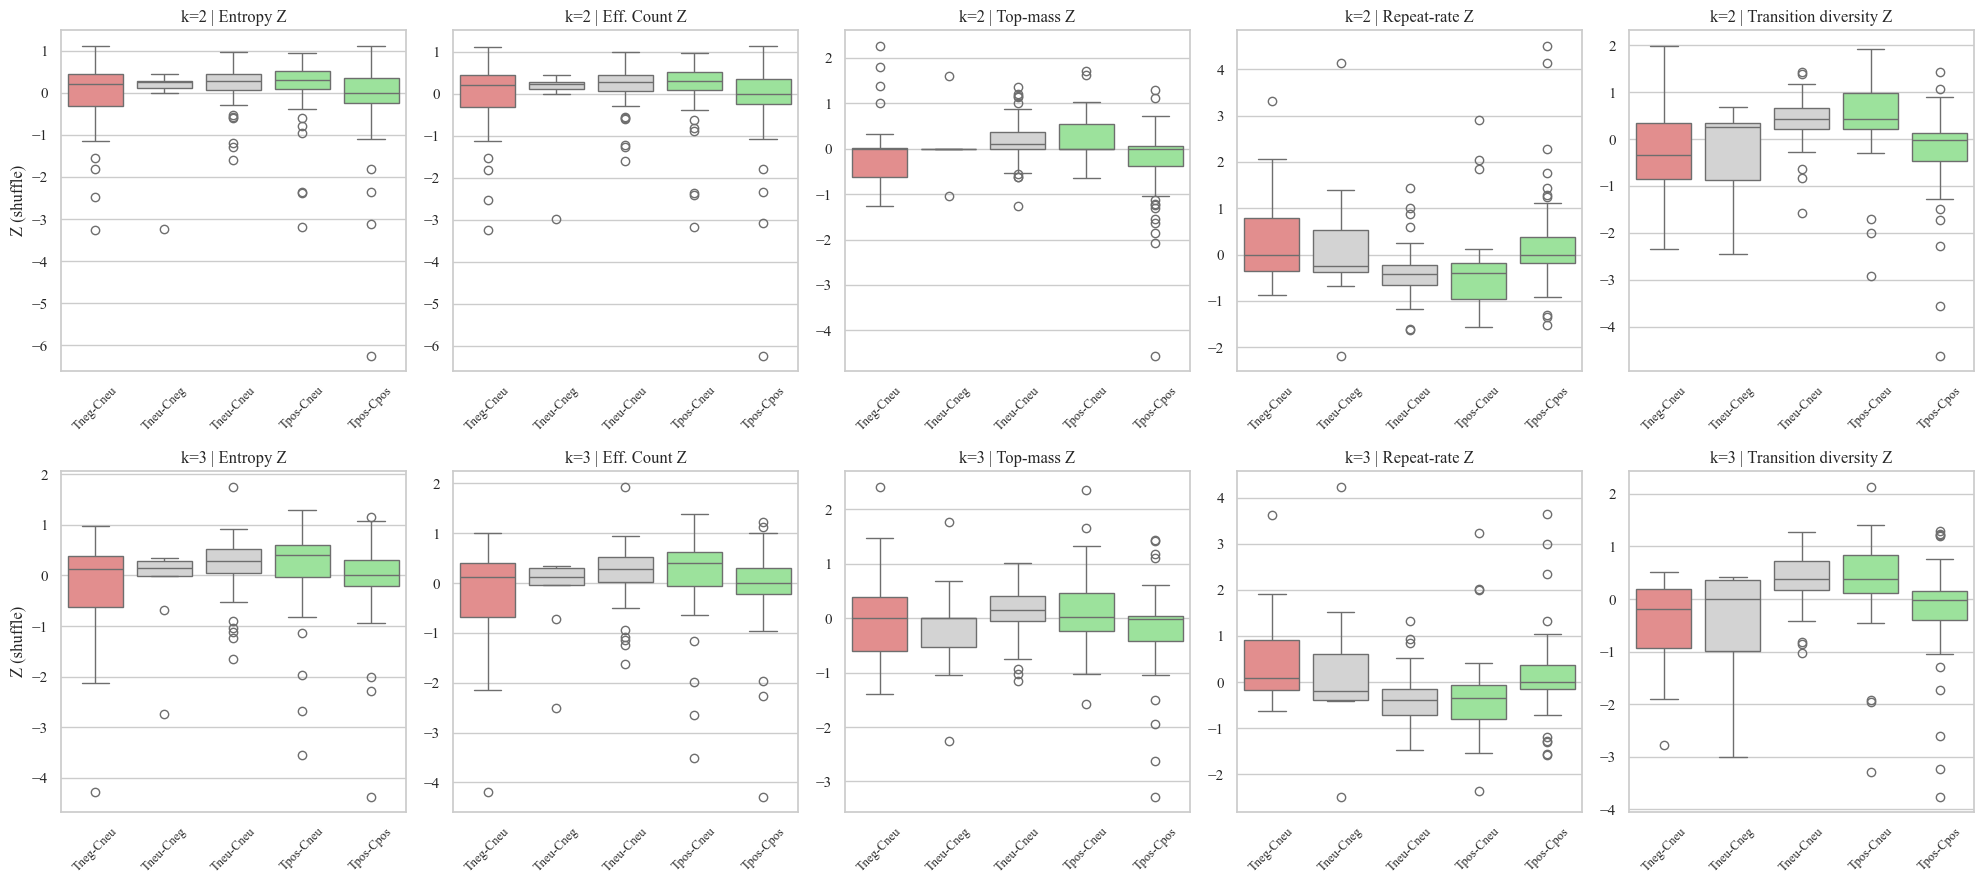

In [6]:
# --- 5) Figure: dyad-level Z-scores by regime_class (shuffle only) ---
palette = {"Tneg": "lightcoral", "Tneu": "lightgray", "Tpos": "lightgreen"}
metric_labels = {
    "motif_entropy_z_shuffle": "Entropy Z",
    "effective_motif_count_z_shuffle": "Eff. Count Z",
    "top_mass_top_n_z_shuffle": "Top-mass Z",
    "repeat_rate_z_shuffle": "Repeat-rate Z",
    "motif_transition_diversity_z_shuffle": "Transition diversity Z",
}

n_metrics = len(metrics)
fig, axes = plt.subplots(2, n_metrics, figsize=(4 * n_metrics, 9), sharey=False)
for row_idx, k_val in enumerate([2, 3]):
    sub = dyad_level[dyad_level["k"] == k_val]
    for col_idx, m in enumerate(metrics):
        ax = axes[row_idx, col_idx]
        sns.boxplot(
            data=sub,
            x="regime_class",
            y=m,
            order=class_order,
            palette=[palette[rc.split('-')[0]] for rc in class_order],
            ax=ax,
        )
        ax.set_title(f"k={k_val} | {metric_labels[m]}")
        ax.set_xlabel("")
        if col_idx == 0:
            ax.set_ylabel("Z (shuffle)")
        else:
            ax.set_ylabel("")
        ax.tick_params(axis="x", rotation=45, labelsize=9)
plt.tight_layout()
fig.savefig(figure_dir / "grammar_shuffle_z_by_regime_class.svg", format="svg")
plt.show()

In [7]:
# --- 6) Compact tables for reporting ---
kw_display = kw_table.copy()
kw_display["metric"] = kw_display["metric"].map(metric_labels)
print("Kruskal-Wallis summary (H, p):")
display(kw_display)

# Build a short narrative summary of dominant contrasts (p<0.001)
narrative_lines = []
for (k_val, m), pairs in dunn_sig_pairs.items():
    strong_pairs = [pair for pair, p in pairs if p < 0.001]
    if strong_pairs:
        metric_name = metric_labels[m]
        joined = ", ".join(strong_pairs)
        narrative_lines.append(f"k={k_val}, {metric_name}: {joined} (all p < .001)")
if narrative_lines:
    print("\nDominant contrasts (p < .001):")
    for line in narrative_lines:
        print("  - " + line)
else:
    print("\nNo dominant contrasts with p < .001.")

Kruskal-Wallis summary (H, p):


,k,metric,H,p
4,2,Transition diversity Z,54.802579,1.631398e-09
3,2,Repeat-rate Z,52.386294,4.899437e-09
2,2,Top-mass Z,30.812900,6.731286e-05
0,2,Entropy Z,18.740611,9.039929e-03
1,2,Eff. Count Z,18.628093,9.435760e-03
9,3,Transition diversity Z,53.164581,3.439848e-09
8,3,Repeat-rate Z,47.665729,4.138520e-08
5,3,Entropy Z,20.117717,5.320952e-03
6,3,Eff. Count Z,19.983144,5.606206e-03
7,3,Top-mass Z,19.646563,6.385891e-03



Dominant contrasts (p < .001):
  - k=2, Top-mass Z: R1 vs R6 (all p < .001)
  - k=2, Repeat-rate Z: R1 vs R4, R1 vs R6 (all p < .001)
  - k=2, Transition diversity Z: R1 vs R4, R1 vs R6 (all p < .001)
  - k=3, Repeat-rate Z: R1 vs R6, R3 vs R6 (all p < .001)
  - k=3, Transition diversity Z: R1 vs R4, R1 vs R6, R3 vs R4, R3 vs R6 (all p < .001)


/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_26322/3203187597.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_26322/3203187597.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


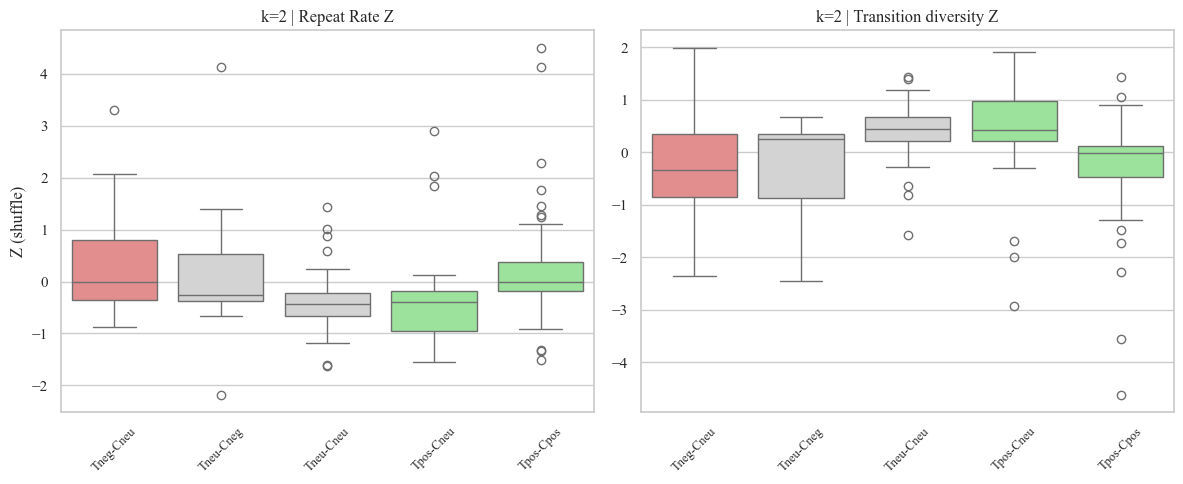

In [8]:
# --- Extra figure: k=3 Top-mass Z (left) and Transition diversity Z (right) ---
k_val = 2
sub = dyad_level[dyad_level["k"] == k_val]
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=False)

# Left: Top-mass Z
sns.boxplot(
    data=sub,
    x="regime_class",
    y="repeat_rate_z_shuffle",
    order=class_order,
    palette=[palette[rc.split('-')[0]] for rc in class_order],
    ax=axes[0],
)
axes[0].set_title(f"k={k_val} | Repeat Rate Z")
axes[0].set_xlabel("")
axes[0].set_ylabel("Z (shuffle)")
axes[0].tick_params(axis="x", rotation=45, labelsize=9)

# Right: Transition diversity Z
sns.boxplot(
    data=sub,
    x="regime_class",
    y="motif_transition_diversity_z_shuffle",
    order=class_order,
    palette=[palette[rc.split('-')[0]] for rc in class_order],
    ax=axes[1],
)
axes[1].set_title(f"k={k_val} | Transition diversity Z")
axes[1].set_xlabel("")
axes[1].set_ylabel("")
axes[1].tick_params(axis="x", rotation=45, labelsize=9)

plt.tight_layout()
fig.savefig(figure_dir / "grammar_k3_topmass_transition_z_by_regime.svg", format="svg")
plt.show()


In [9]:
# --- 7) Export grammar stats to CSV (same pattern as catRQA) ---

export_dir = project_root / "artifacts" / "supplementary_tables"
export_dir.mkdir(parents=True, exist_ok=True)

# Metrics to export
export_metrics = [
    "motif_entropy_z_shuffle",
    "effective_motif_count_z_shuffle",
    "top_mass_top_n_z_shuffle",
    "repeat_rate_z_shuffle",
    "motif_transition_diversity_z_shuffle",
]

# 1) Regime means by k
grammar_means_df = (
    dyad_level
    .groupby(["k", "regime_class"], as_index=False)[export_metrics]
    .mean()
)

# 2) Kruskal-Wallis summary and Dunn pairwise (long)
kw_rows = []
dunn_rows = []

for k_val in [2, 3]:
    sub = dyad_level[dyad_level["k"] == k_val]
    for metric in export_metrics:
        sub_metric = sub.dropna(subset=[metric, "regime"])
        groups = [
            sub_metric.loc[sub_metric["regime"] == reg, metric].values
            for reg in sorted(sub_metric["regime"].unique())
        ]
        groups = [g for g in groups if len(g) > 0]

        if len(groups) < 2:
            continue

        H, p_kw = kruskal(*groups)
        kw_rows.append({
            "k": k_val,
            "Metric": metric,
            "KW_H_Stat": H,
            "KW_P_Value": p_kw,
            "N_Groups": len(groups),
        })

        dunn_df = sp.posthoc_dunn(
            sub_metric,
            val_col=metric,
            group_col="regime",
            p_adjust="bonferroni",
        )

        # Keep canonical order for present regimes only
        present_regs = [reg for reg in order if reg in dunn_df.index]
        dunn_df = dunn_df.loc[present_regs, present_regs]

        # Label as class + regime number, e.g., Tneu-Cneu (R4)
        reg_labels = [f"{regime_class_by_regime[r]} (R{order_rank[r] + 1})" for r in present_regs]
        dunn_df.index = reg_labels
        dunn_df.columns = reg_labels

        dunn_long = (
            dunn_df
            .rename_axis(index="Regime_1", columns="Regime_2")
            .stack()
            .reset_index(name="P_Value")
        )
        dunn_long["k"] = k_val
        dunn_long["Metric"] = metric
        dunn_long["KW_H_Stat"] = H
        dunn_long["KW_P_Value"] = p_kw
        dunn_rows.append(dunn_long)

grammar_kw_df = pd.DataFrame(kw_rows)
grammar_dunn_df = pd.concat(dunn_rows, ignore_index=True) if dunn_rows else pd.DataFrame()

# 3) Save files
out_kw = export_dir / "S3_grammar_kruskal_summary.csv"
out_dunn = export_dir / "S3_grammar_dunn_pvalues_long.csv"
out_means = export_dir / "S3_grammar_regime_means.csv"

grammar_kw_df.to_csv(out_kw, index=False)
grammar_dunn_df.to_csv(out_dunn, index=False)
grammar_means_df.to_csv(out_means, index=False)

print(f"Saved grammar Kruskal summary to: {out_kw}")
print(f"Saved grammar Dunn p-values (long) to: {out_dunn}")
print(f"Saved grammar regime means to: {out_means}")

print("\nPreview — grammar Kruskal summary:")
display(grammar_kw_df)
print("\nPreview — grammar regime means:")
display(grammar_means_df.head())

Saved grammar Kruskal summary to: /Users/cartersale/Research/projects/affect_dynamics/artifacts/supplementary_tables/S3_grammar_kruskal_summary.csv
Saved grammar Dunn p-values (long) to: /Users/cartersale/Research/projects/affect_dynamics/artifacts/supplementary_tables/S3_grammar_dunn_pvalues_long.csv
Saved grammar regime means to: /Users/cartersale/Research/projects/affect_dynamics/artifacts/supplementary_tables/S3_grammar_regime_means.csv

Preview — grammar Kruskal summary:


/var/folders/fg/dc68zxv12sz5v55n18sqsvmw0000gn/T/ipykernel_26322/2286933192.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["k", "regime_class"], as_index=False)[export_metrics]


,k,Metric,KW_H_Stat,KW_P_Value,N_Groups
0,2,motif_entropy_z_shuffle,18.740611,9.039929e-03,8
1,2,effective_motif_count_z_shuffle,18.628093,9.435760e-03,8
2,2,top_mass_top_n_z_shuffle,30.812900,6.731286e-05,8
3,2,repeat_rate_z_shuffle,52.386294,4.899437e-09,8
4,2,motif_transition_diversity_z_shuffle,54.802579,1.631398e-09,8
5,3,motif_entropy_z_shuffle,20.117717,5.320952e-03,8
6,3,effective_motif_count_z_shuffle,19.983144,5.606206e-03,8
7,3,top_mass_top_n_z_shuffle,19.646563,6.385891e-03,8
8,3,repeat_rate_z_shuffle,47.665729,4.138520e-08,8
9,3,motif_transition_diversity_z_shuffle,53.164581,3.439848e-09,8



Preview — grammar regime means:


,k,regime_class,motif_entropy_z_shuffle,effective_motif_count_z_shuffle,top_mass_top_n_z_shuffle,repeat_rate_z_shuffle,motif_transition_diversity_z_shuffle
0,2,Tneg-Cneu,-0.181421,-0.183262,-0.051624,0.332473,-0.289994
1,2,Tneu-Cneg,-0.113840,-0.092147,0.056616,0.216349,-0.351416
2,2,Tneu-Cneu,0.201542,0.201266,0.167904,-0.398514,0.395963
3,2,Tpos-Cneu,0.076526,0.077523,0.263965,-0.375845,0.393122
4,2,Tpos-Cpos,-0.137942,-0.138904,-0.273983,0.224073,-0.269339


In [10]:
# --- Authoritative K=8 grammar exports for manuscript tables ---
# Rebuilds S3 tables from the K=8 episode file and canonical R1-R8 labels exported by hmm_outputs.

from scipy.stats import kruskal
import scikit_posthocs as sp

project_root = Path.cwd().resolve()
if not (project_root / "artifacts").exists():
    project_root = project_root.parent

export_dir = project_root / "artifacts" / "supplementary_tables"
export_dir.mkdir(parents=True, exist_ok=True)

emission_df = pd.read_csv(export_dir / "S1_hmm_regime_emissions.csv")
state_to_regime = dict(zip(emission_df["Original_State_Index"], emission_df["Regime_Number"]))
state_to_label = dict(zip(emission_df["Original_State_Index"], emission_df["Regime_Label"]))

gram_episode_df = pd.read_csv(project_root / "artifacts" / "joint_affect_grammar_K8" / "grammar_episode_results.csv")
gram_episode_df["Regime_Number"] = gram_episode_df["regime"].map(state_to_regime)
gram_episode_df["Regime_Label"] = gram_episode_df["regime"].map(state_to_label)

gram_metrics = [
    "motif_entropy_z_shuffle",
    "effective_motif_count_z_shuffle",
    "top_mass_top_n_z_shuffle",
    "repeat_rate_z_shuffle",
    "motif_transition_diversity_z_shuffle",
]

def _weighted_mean(df: pd.DataFrame, value_col: str, weight_col: str = "duration") -> float:
    sub = df.dropna(subset=[value_col, weight_col])
    total_weight = sub[weight_col].sum()
    if sub.empty or total_weight == 0:
        return np.nan
    return float(np.average(sub[value_col], weights=sub[weight_col]))

gram_session_df = (
    gram_episode_df.groupby(["session_id", "dyad_id", "Regime_Number", "Regime_Label", "k"], group_keys=False)
    .apply(lambda df: pd.Series({
        **{metric: _weighted_mean(df, metric) for metric in gram_metrics},
        "Duration": float(df["duration"].sum()),
        "N_Episodes": int(len(df)),
    }), include_groups=False)
    .reset_index()
)

gram_dyad_df = (
    gram_session_df.groupby(["dyad_id", "Regime_Number", "Regime_Label", "k"], group_keys=False)
    .apply(lambda df: pd.Series({
        **{metric: _weighted_mean(df, metric, "Duration") for metric in gram_metrics},
        "Duration": float(df["Duration"].sum()),
        "N_Sessions": int(df["session_id"].nunique()),
        "N_Episodes": int(df["N_Episodes"].sum()),
    }), include_groups=False)
    .reset_index()
)

gram_means_df = (
    gram_dyad_df.groupby(["k", "Regime_Number", "Regime_Label"], as_index=False)[gram_metrics]
    .mean()
)
gram_coverage_df = (
    gram_dyad_df.groupby(["k", "Regime_Number", "Regime_Label"], as_index=False)
    .agg(N_Dyads=("dyad_id", "nunique"), Duration=("Duration", "sum"), N_Episodes=("N_Episodes", "sum"))
)

kw_rows = []
dunn_rows = []
for k_val in sorted(gram_dyad_df["k"].dropna().unique()):
    sub_k = gram_dyad_df[gram_dyad_df["k"] == k_val]
    for metric in gram_metrics:
        sub = sub_k.dropna(subset=[metric, "Regime_Number"])
        groups = [g[metric].values for _, g in sub.groupby("Regime_Number") if len(g) > 0]
        if len(groups) < 2:
            continue
        H, p_kw = kruskal(*groups)
        kw_rows.append({"k": int(k_val), "Metric": metric, "KW_H_Stat": float(H), "KW_P_Value": float(p_kw), "N_Groups": len(groups)})
        dunn = sp.posthoc_dunn(sub, val_col=metric, group_col="Regime_Number", p_adjust="bonferroni")
        for r1 in dunn.index:
            for r2 in dunn.columns:
                dunn_rows.append({
                    "Regime_1": r1,
                    "Regime_2": r2,
                    "P_Value": float(dunn.loc[r1, r2]),
                    "k": int(k_val),
                    "Metric": metric,
                    "KW_H_Stat": float(H),
                    "KW_P_Value": float(p_kw),
                })

gram_kw_df = pd.DataFrame(kw_rows)
gram_dunn_df = pd.DataFrame(dunn_rows)

gram_means_df.to_csv(export_dir / "S3_grammar_regime_means.csv", index=False)
gram_coverage_df.to_csv(export_dir / "S3_grammar_regime_coverage.csv", index=False)
gram_kw_df.to_csv(export_dir / "S3_grammar_kruskal_summary.csv", index=False)
gram_dunn_df.to_csv(export_dir / "S3_grammar_dunn_pvalues_long.csv", index=False)
gram_dyad_df.to_csv(export_dir / "S3_grammar_dyad_level_metrics.csv", index=False)

print("Saved authoritative K=8 grammar S3 tables to", export_dir)
display(gram_coverage_df)
display(gram_kw_df)



Saved authoritative K=8 grammar S3 tables to /Users/cartersale/Research/projects/affect_dynamics/artifacts/supplementary_tables


,k,Regime_Number,Regime_Label,N_Dyads,Duration,N_Episodes
0,2,R1,Tneg-Cneg,69,8511.0,792.0
1,2,R2,Tneg-Cneu,81,10708.0,1108.0
2,2,R3,Tneu-Cneg,93,34994.0,3294.0
3,2,R4,Tneu-Cneu-1,88,23793.0,866.0
4,2,R5,Tneu-Cneu-2,94,84649.0,6403.0
5,2,R6,Tneu-Cpos,52,1518.0,187.0
6,2,R7,Tpos-Cneg,82,8411.0,970.0
7,2,R8,Tpos-Cneu,90,11582.0,1443.0
8,3,R1,Tneg-Cneg,69,8511.0,792.0
9,3,R2,Tneg-Cneu,81,10708.0,1108.0


,k,Metric,KW_H_Stat,KW_P_Value,N_Groups
0,2,motif_entropy_z_shuffle,12.735031,7.883358e-02,8
1,2,effective_motif_count_z_shuffle,12.683591,8.020331e-02,8
2,2,top_mass_top_n_z_shuffle,29.539538,1.153152e-04,8
3,2,repeat_rate_z_shuffle,50.074218,1.396825e-08,8
4,2,motif_transition_diversity_z_shuffle,49.520033,1.794286e-08,8
5,3,motif_entropy_z_shuffle,16.652036,1.978309e-02,8
6,3,effective_motif_count_z_shuffle,16.778322,1.888290e-02,8
7,3,top_mass_top_n_z_shuffle,22.182924,2.362324e-03,8
8,3,repeat_rate_z_shuffle,41.456994,6.614138e-07,8
9,3,motif_transition_diversity_z_shuffle,43.246946,2.988669e-07,8
